# Project 1: Retail Sales Performance Analysis
## Data Analytics Internship — Month 1

**Objective:** Analyse 24 months of retail transactions to uncover revenue trends, category performance, regional patterns, and actionable business insights.

**Dataset:** 12,594 records | Jan 2023 – Dec 2024 | 6 Categories | 5 Regions

**Tools:** Python, Pandas, Matplotlib, NumPy, SciPy

---
### Table of Contents
1. [Environment Setup & Data Loading](#1)
2. [Data Validation & Quality Checks](#2)
3. [Exploratory Data Analysis](#3)
4. [Revenue & Profit Trend Analysis](#4)
5. [Category Performance Analysis](#5)
6. [Regional Analysis](#6)
7. [Customer & Payment Segmentation](#7)
8. [Statistical & Correlation Analysis](#8)
9. [Operational Analysis](#9)
10. [Business Recommendations](#10)

## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Global plot style
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.facecolor':  '#FAFAFA',
    'axes.facecolor':    '#FAFAFA',
})

# Color palettes
CAT_COLORS = {
    'Electronics':            '#1B4F72',
    'Clothing':               '#E74C3C',
    'Food & Grocery':         '#27AE60',
    'Home & Living':          '#F39C12',
    'Sports & Fitness':       '#8E44AD',
    'Beauty & Personal Care': '#E91E8C'
}
REG_COLORS = {
    'North':'#2E86C1', 'South':'#E74C3C',
    'East':'#27AE60',  'West':'#F39C12', 'Central':'#8E44AD'
}

def fmt_cr(x, _=None):  return f'Rs.{x/1e7:.1f}Cr'
def fmt_lk(x, _=None):  return f'Rs.{x/1e5:.0f}L'

print('Libraries loaded successfully')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Libraries loaded successfully
Pandas: 2.2.3 | NumPy: 2.0.2


In [2]:
# Load dataset  — place retail_sales_data.csv in the same folder as this notebook
df = pd.read_csv('retail_sales_data.csv', parse_dates=['date'])

print(f'Dataset Loaded')
print(f'  Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'  Memory     : {df.memory_usage(deep=True).sum()/1024:.1f} KB')
print(f'  Date range : {df["date"].min().date()}  to  {df["date"].max().date()}')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'retail_sales_data.csv'

## 2. Data Validation & Quality Checks

In [ ]:
print('=== DATA TYPES ===')
print(df.dtypes)
print()

print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found!')
print()

print('=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum()}')
print()

print('=== UNIQUE VALUES PER CATEGORY COLUMN ===')
for col in ['category', 'region', 'payment_mode', 'age_segment']:
    print(f'{col:25s}: {df[col].nunique()} unique -> {sorted(df[col].unique())}')

=== DATA TYPES ===
order_id                 object
date             datetime64[ns]
year                      int64
month                     int64
month_name               object
quarter                  object
weekday                  object
category                 object
region                   object
sales_rep                object
payment_mode             object
unit_price              float64
quantity                  int64
discount_pct              int64
revenue                 float64
cost                    float64
profit                  float64
profit_margin           float64
age_segment              object
returned                   bool
dtype: object

=== MISSING VALUES ===
No missing values found!

=== DUPLICATES ===
Duplicate rows: 0

=== UNIQUE VALUES PER CATEGORY COLUMN ===
category                 : 6 unique -> ['Beauty & Personal Care', 'Clothing', 'Electronics', 'Food & Grocery', 'Home & Living', 'Sports & Fitness']
region                   : 5 unique -> ['Central'

In [ ]:
print('=== BUSINESS RULE VALIDATIONS ===')
checks = {
    'Revenue > 0':          (df['revenue'] > 0).all(),
    'Profit < Revenue':     (df['profit'] < df['revenue']).all(),
    'Discount in [0,25]':   df['discount_pct'].between(0, 25).all(),
    'Quantity >= 1':        (df['quantity'] >= 1).all(),
    'Valid years 2023/24':  df['year'].isin([2023, 2024]).all(),
    'Margin in [0,100]':    df['profit_margin'].between(0, 100).all(),
    'Unique order IDs':     df['order_id'].nunique() == len(df),
}
for check, result in checks.items():
    print(f'{"PASS" if result else "FAIL"}  {check}')

=== BUSINESS RULE VALIDATIONS ===
PASS  Revenue > 0
PASS  Profit < Revenue
PASS  Discount in [0,25]
PASS  Quantity >= 1
PASS  Valid years 2023/24
PASS  Margin in [0,100]
PASS  Unique order IDs


## 3. Exploratory Data Analysis

In [ ]:
print('=== STATISTICAL SUMMARY ===')
print(df[['revenue','profit','quantity','discount_pct','profit_margin']].describe().round(2))

print('\n=== KEY KPIs ===')
total_rev    = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = len(df)
avg_order    = df['revenue'].mean()
margin       = total_profit / total_rev * 100
total_2023   = df[df['year']==2023]['revenue'].sum()
total_2024   = df[df['year']==2024]['revenue'].sum()
yoy_growth   = (total_2024 - total_2023) / total_2023 * 100

print(f'Total Revenue   : Rs.{total_rev:>15,.2f}  ({total_rev/1e7:.2f} Crores)')
print(f'Total Profit    : Rs.{total_profit:>15,.2f}  ({total_profit/1e7:.2f} Crores)')
print(f'Total Orders    : {total_orders:>20,}')
print(f'Avg Order Value : Rs.{avg_order:>15,.2f}')
print(f'Overall Margin  : {margin:>20.2f}%')
print(f'YoY Growth      : {yoy_growth:>19.1f}%')

=== STATISTICAL SUMMARY ===
         revenue    profit  quantity  discount_pct  profit_margin
count  12,594.00 12,594.00 12,594.00     12,594.00      12,594.00
mean   20,710.19  4,858.93      1.40          4.55          30.35
std    38,259.19  7,287.70      0.84          6.91          10.41
min        43.68      9.61      1.00          0.00          18.00
25%     2,074.28    567.46      1.00          0.00          22.00
50%     6,072.42  2,221.84      1.00          0.00          30.00
75%    21,995.36  6,531.46      2.00          5.00          42.00
max   498,650.67 89,757.12      5.00         25.00          48.00

=== KEY KPIs ===
Total Revenue   : Rs. 260,824,080.46  (26.08 Crores)
Total Profit    : Rs.  61,193,352.20  (6.12 Crores)
Total Orders    :               12,594
Avg Order Value : Rs.      20,710.19
Overall Margin  :                23.46%
YoY Growth      :                -1.1%


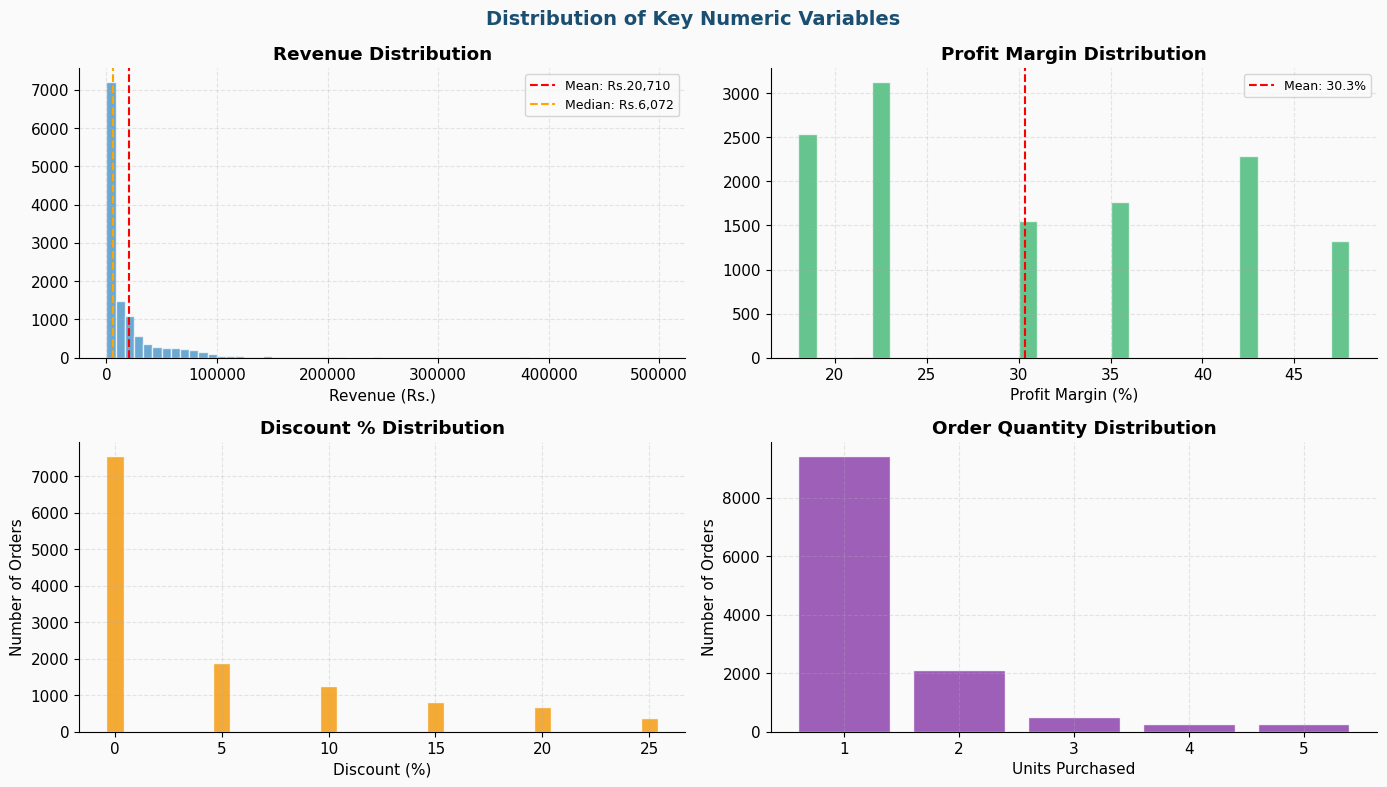

In [ ]:
# ── EDA: Distribution Plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of Key Numeric Variables', fontsize=14, fontweight='bold', color='#1B4F72')

# Revenue
axes[0,0].hist(df['revenue'], bins=60, color='#2E86C1', alpha=0.7, edgecolor='white')
axes[0,0].axvline(df['revenue'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: Rs.{df["revenue"].mean():,.0f}')
axes[0,0].axvline(df['revenue'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: Rs.{df["revenue"].median():,.0f}')
axes[0,0].set_title('Revenue Distribution', fontweight='bold')
axes[0,0].set_xlabel('Revenue (Rs.)')
axes[0,0].legend(fontsize=9)

# Profit Margin
axes[0,1].hist(df['profit_margin'], bins=30, color='#27AE60', alpha=0.7, edgecolor='white')
axes[0,1].axvline(df['profit_margin'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["profit_margin"].mean():.1f}%')
axes[0,1].set_title('Profit Margin Distribution', fontweight='bold')
axes[0,1].set_xlabel('Profit Margin (%)')
axes[0,1].legend(fontsize=9)

# Discount
disc_counts = df['discount_pct'].value_counts().sort_index()
axes[1,0].bar(disc_counts.index, disc_counts.values, color='#F39C12', alpha=0.85, edgecolor='white')
axes[1,0].set_title('Discount % Distribution', fontweight='bold')
axes[1,0].set_xlabel('Discount (%)')
axes[1,0].set_ylabel('Number of Orders')

# Quantity
qty_counts = df['quantity'].value_counts().sort_index()
axes[1,1].bar(qty_counts.index, qty_counts.values, color='#8E44AD', alpha=0.85, edgecolor='white')
axes[1,1].set_title('Order Quantity Distribution', fontweight='bold')
axes[1,1].set_xlabel('Units Purchased')
axes[1,1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

## 4. Revenue & Profit Trend Analysis

In [ ]:
# Aggregations
monthly = df.groupby(['year','month']).agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    orders=('order_id','count')
).reset_index()
monthly['label'] = monthly.apply(lambda r: f"{int(r.year)}-{int(r.month):02d}", axis=1)

print('=== MONTHLY SUMMARY (first 6) ===')
print(monthly[['label','revenue','profit','orders']].head(6).to_string(index=False))

print('\n=== YEAR-OVER-YEAR ===')
yearly = df.groupby('year').agg(revenue=('revenue','sum'), profit=('profit','sum'), orders=('order_id','count'))
yearly['margin_%'] = (yearly['profit'] / yearly['revenue'] * 100).round(2)
yearly['yoy_growth_%'] = yearly['revenue'].pct_change().mul(100).round(2)
print(yearly)

=== MONTHLY SUMMARY (first 6) ===
  label      revenue       profit  orders
2023-01 7,418,863.47 1,737,755.90     334
2023-02 6,906,235.75 1,629,060.24     305
2023-03 9,945,068.55 2,382,233.53     513
2023-04 8,529,977.71 2,021,160.31     471
2023-05 9,160,724.27 2,193,125.94     449
2023-06 8,999,673.03 2,170,039.12     495

=== YEAR-OVER-YEAR ===
            revenue        profit  orders  margin_%  yoy_growth_%
year                                                             
2023 131,123,566.97 30,806,045.80    6275     23.49           NaN
2024 129,700,513.49 30,387,306.40    6319     23.43         -1.09


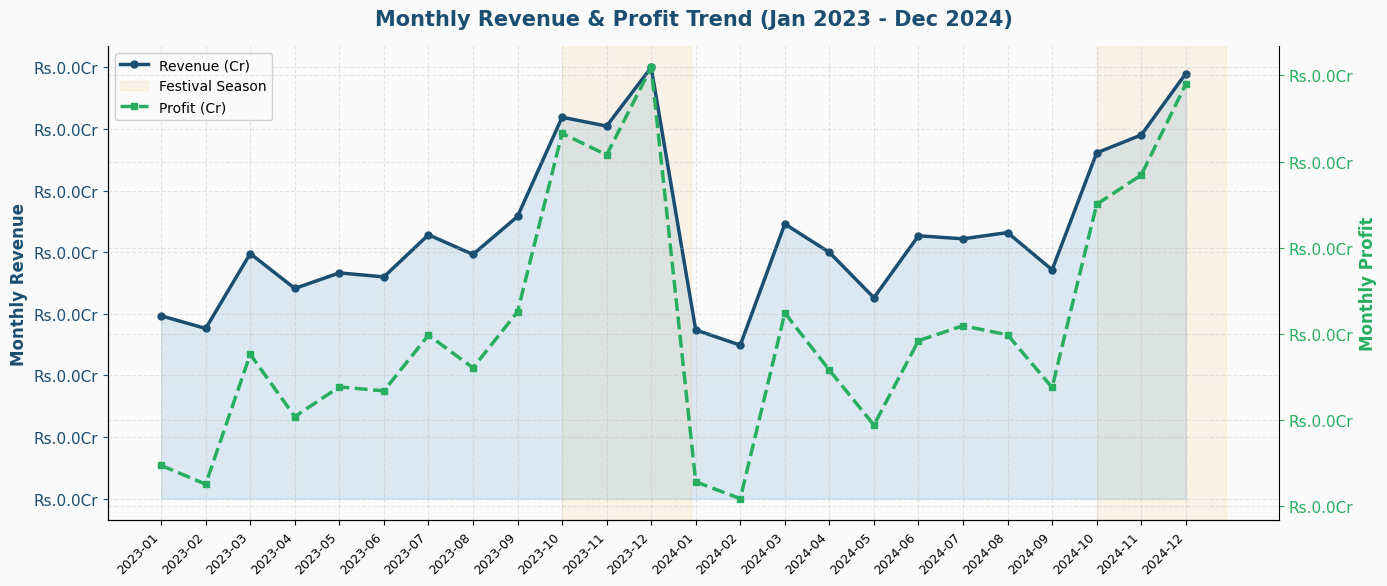

In [ ]:
# ── VIZ 1: Monthly Revenue & Profit Trend ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)

x = range(len(monthly))

# Revenue area + line
ax1.fill_between(x, monthly['revenue']/1e7, alpha=0.15, color='#2E86C1')
ax1.plot(x, monthly['revenue']/1e7, 'o-', color='#1B4F72', linewidth=2.5, markersize=5, label='Revenue (Cr)')

# Profit dashed line
ax2.plot(x, monthly['profit']/1e7, 's--', color='#27AE60', linewidth=2.5, markersize=5, label='Profit (Cr)')

# Festival season shading (Oct–Dec = indices 9,10,11 and 21,22,23)
for offset in [0, 12]:
    ax1.axvspan(offset+9, offset+11.9, alpha=0.08, color='#F39C12',
                label='Festival Season' if offset == 0 else '')

ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly['label'], rotation=45, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_cr))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_cr))
ax1.set_ylabel('Monthly Revenue', color='#1B4F72', fontweight='bold', fontsize=12)
ax2.set_ylabel('Monthly Profit',  color='#27AE60', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', colors='#1B4F72')
ax2.tick_params(axis='y', colors='#27AE60')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='upper left', framealpha=0.9, fontsize=10)

ax1.set_title('Monthly Revenue & Profit Trend (Jan 2023 - Dec 2024)',
              fontsize=15, fontweight='bold', color='#1B4F72', pad=15)
plt.tight_layout()
plt.show()

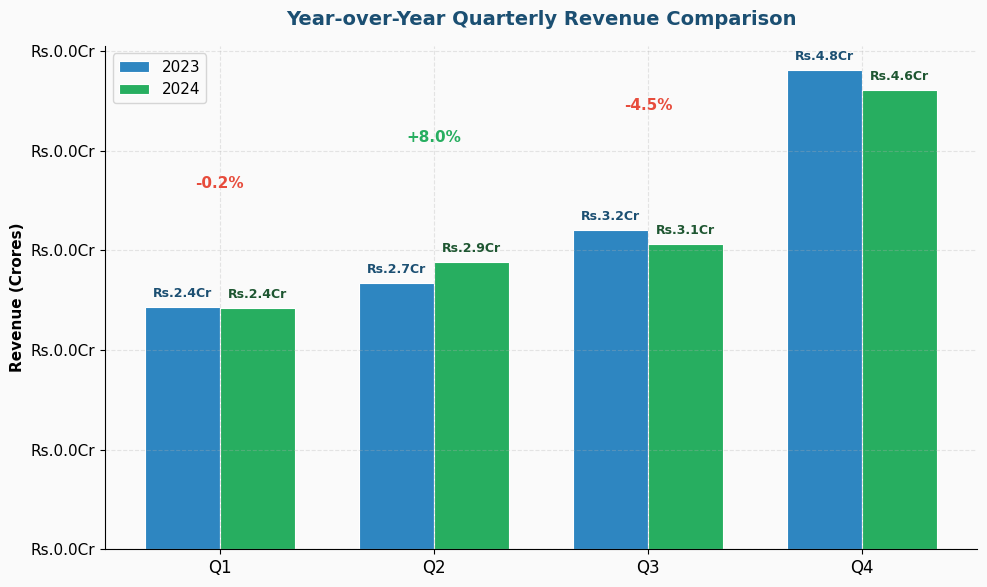

In [ ]:
# ── VIZ 2: Year-over-Year Quarterly Comparison ───────────────────────────────
qtr = df.groupby(['year','quarter']).agg(revenue=('revenue','sum')).reset_index()
q2023 = qtr[qtr['year']==2023].set_index('quarter')['revenue'] / 1e7
q2024 = qtr[qtr['year']==2024].set_index('quarter')['revenue'] / 1e7
quarters = ['Q1','Q2','Q3','Q4']
x = np.arange(len(quarters))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FAFAFA')

b1 = ax.bar(x - width/2, [q2023.get(q,0) for q in quarters], width,
            label='2023', color='#2E86C1', edgecolor='white', linewidth=0.8)
b2 = ax.bar(x + width/2, [q2024.get(q,0) for q in quarters], width,
            label='2024', color='#27AE60', edgecolor='white', linewidth=0.8)

# Value labels on bars
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'Rs.{bar.get_height():.1f}Cr', ha='center', fontsize=9, fontweight='bold', color='#1B4F72')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'Rs.{bar.get_height():.1f}Cr', ha='center', fontsize=9, fontweight='bold', color='#1E5631')

# Growth % annotation above each quarter
for i, q in enumerate(quarters):
    v23 = q2023.get(q, 0)
    v24 = q2024.get(q, 0)
    if v23 > 0:
        growth = (v24 - v23) / v23 * 100
        color  = '#27AE60' if growth >= 0 else '#E74C3C'
        ax.annotate(f'{growth:+.1f}%', xy=(i, max(v23,v24)+1.2),
                    ha='center', fontsize=11, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(quarters, fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_cr))
ax.set_ylabel('Revenue (Crores)', fontweight='bold')
ax.set_title('Year-over-Year Quarterly Revenue Comparison',
             fontsize=14, fontweight='bold', color='#1B4F72', pad=15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 5. Category Performance Analysis

In [ ]:
cat_stats = df.groupby('category').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    orders=('order_id','count'),
    avg_margin=('profit_margin','mean'),
    return_rate=('returned','mean')
).reset_index().sort_values('revenue', ascending=False)
cat_stats['revenue_share_%'] = (cat_stats['revenue'] / cat_stats['revenue'].sum() * 100).round(1)

print('=== CATEGORY PERFORMANCE ===')
print(cat_stats[['category','revenue','profit','orders','avg_margin','revenue_share_%']].to_string(index=False))

=== CATEGORY PERFORMANCE ===
              category        revenue        profit  orders  avg_margin  revenue_share_%
           Electronics 171,736,897.07 30,912,641.59    2542       18.00            65.80
      Sports & Fitness  33,732,180.43 10,119,654.29    1545       30.00            12.90
         Home & Living  31,337,155.93 10,968,004.61    1764       35.00            12.00
              Clothing  13,363,149.71  5,612,522.66    2285       42.00             5.10
        Food & Grocery   5,898,944.74  1,297,767.72    3139       22.00             2.30
Beauty & Personal Care   4,755,752.58  2,282,761.33    1319       48.00             1.80


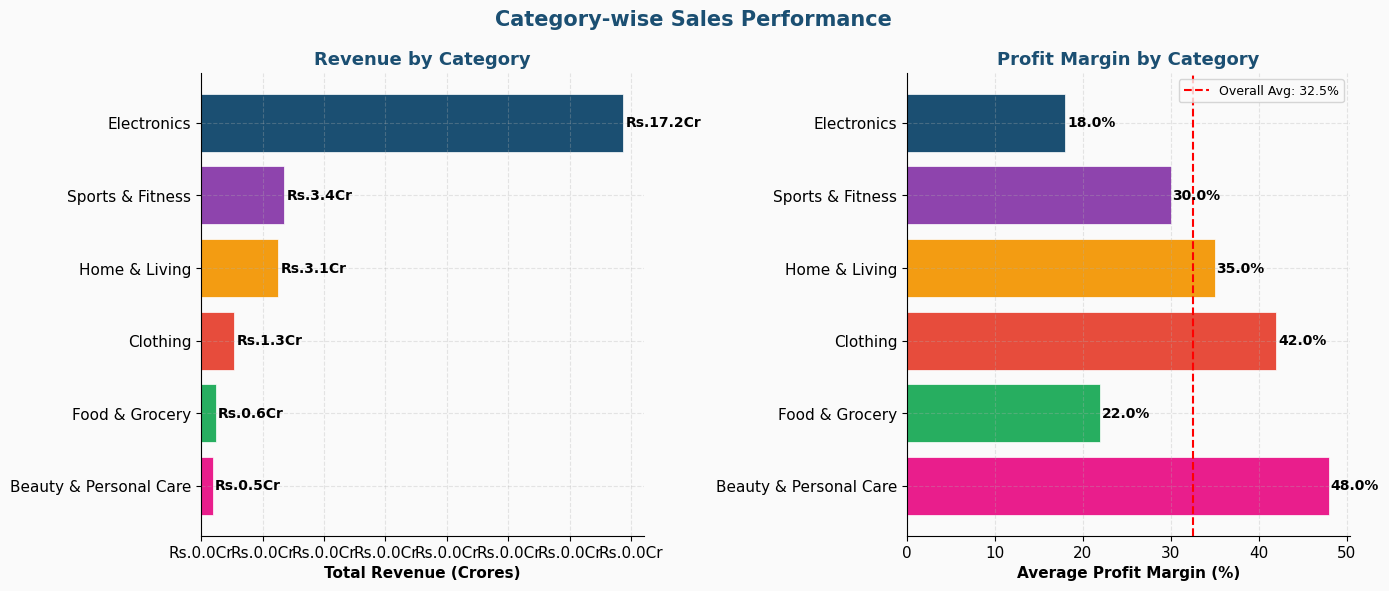

In [ ]:
# ── VIZ 3: Category Revenue & Profit Margin ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Category-wise Sales Performance', fontsize=15, fontweight='bold', color='#1B4F72')

cats   = cat_stats['category'].tolist()
colors = [CAT_COLORS[c] for c in cats]

# Left: Revenue horizontal bar
bars = axes[0].barh(cats[::-1], cat_stats['revenue'][::-1]/1e7,
                    color=colors[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, cat_stats['revenue'][::-1]/1e7):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'Rs.{val:.1f}Cr', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Total Revenue (Crores)', fontweight='bold')
axes[0].set_title('Revenue by Category', fontsize=13, fontweight='bold', color='#1B4F72')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_cr))

# Right: Profit margin horizontal bar
bars2 = axes[1].barh(cats[::-1], cat_stats['avg_margin'][::-1],
                     color=colors[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, cat_stats['avg_margin'][::-1]):
    axes[1].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
avg_margin_all = cat_stats['avg_margin'].mean()
axes[1].axvline(avg_margin_all, color='red', linestyle='--', linewidth=1.5,
                label=f'Overall Avg: {avg_margin_all:.1f}%')
axes[1].set_xlabel('Average Profit Margin (%)', fontweight='bold')
axes[1].set_title('Profit Margin by Category', fontsize=13, fontweight='bold', color='#1B4F72')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Regional Analysis

In [ ]:
reg_stats = df.groupby('region').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    orders=('order_id','count'),
    avg_margin=('profit_margin','mean')
).reset_index().sort_values('revenue', ascending=False)
reg_stats['rev_share_%'] = (reg_stats['revenue'] / reg_stats['revenue'].sum() * 100).round(1)

print('=== REGIONAL PERFORMANCE ===')
print(reg_stats.to_string(index=False))

print('\n=== REVENUE PIVOT: CATEGORY x REGION (Lakhs) ===')
pivot = df.pivot_table(values='revenue', index='category', columns='region', aggfunc='sum') / 1e5
print(pivot.round(1))

=== REGIONAL PERFORMANCE ===
 region       revenue        profit  orders  avg_margin  rev_share_%
   West 73,907,880.41 17,283,163.96    3163       30.08        28.30
  North 62,630,549.16 14,635,961.61    2787       30.39        24.00
   East 49,330,017.29 11,655,562.68    2549       30.75        18.90
  South 39,758,641.12  9,310,780.49    2207       30.32        15.20
Central 35,196,992.48  8,307,883.46    1888       30.23        13.50

=== REVENUE PIVOT: CATEGORY x REGION (Lakhs) ===
region                  Central   East  North  South   West
category                                                   
Beauty & Personal Care     6.30   9.40  12.20   7.60  12.10
Clothing                  18.30  26.90  30.80  21.00  36.60
Electronics              227.80 322.90 416.60 263.50 486.70
Food & Grocery             8.10  11.00  13.90   9.10  16.80
Home & Living             42.70  65.30  73.70  46.00  85.70
Sports & Fitness          48.90  57.70  79.20  50.40 101.10


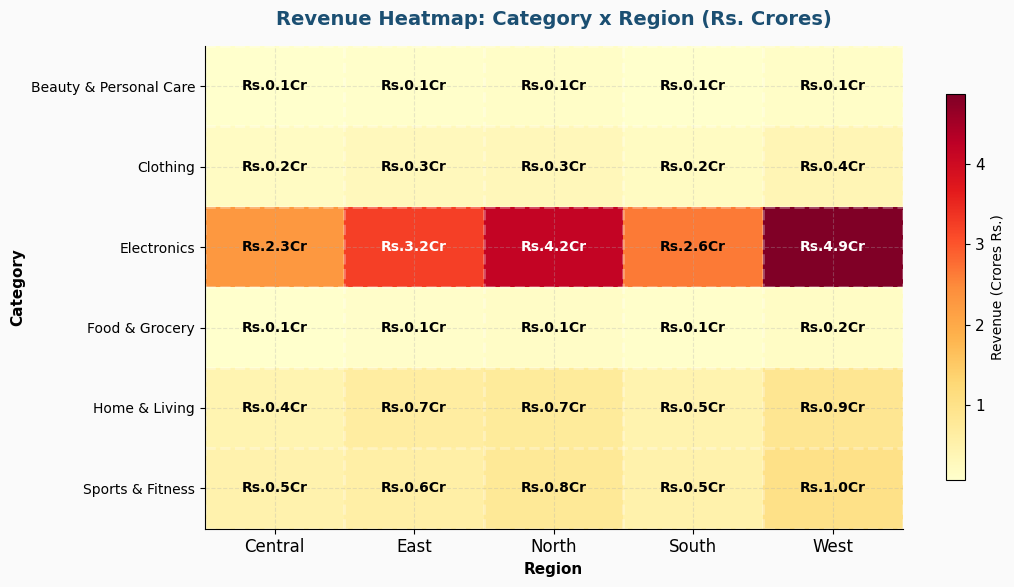

In [ ]:
# ── VIZ 4: Regional Heatmap (Category x Region) ───────────────────────────────
pivot_data = df.pivot_table(values='revenue', index='category', columns='region', aggfunc='sum') / 1e7
categories = pivot_data.index.tolist()
regions    = pivot_data.columns.tolist()
values     = pivot_data.values

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAFA')

im = ax.imshow(values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(regions)))
ax.set_yticks(range(len(categories)))
ax.set_xticklabels(regions, fontsize=12)
ax.set_yticklabels(categories, fontsize=10)

# Annotate each cell
for i in range(len(categories)):
    for j in range(len(regions)):
        val = values[i, j]
        text_color = 'white' if val > values.max()*0.6 else 'black'
        ax.text(j, i, f'Rs.{val:.1f}Cr', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Revenue (Crores Rs.)', fontsize=10)

ax.set_title('Revenue Heatmap: Category x Region (Rs. Crores)',
             fontsize=14, fontweight='bold', color='#1B4F72', pad=15)
ax.set_xlabel('Region', fontweight='bold')
ax.set_ylabel('Category', fontweight='bold')

# Draw grid lines between cells
ax.set_xticks(np.arange(-0.5, len(regions),  1), minor=True)
ax.set_yticks(np.arange(-0.5, len(categories), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.show()

## 7. Customer & Payment Segmentation

In [ ]:
pay_rev = df.groupby('payment_mode')['revenue'].sum().sort_values(ascending=False)
age_rev = df.groupby('age_segment')['revenue'].sum().sort_index()

print('=== PAYMENT MODE ===')
for mode, rev in pay_rev.items():
    print(f'  {mode:20s}: Rs.{rev/1e7:.2f} Cr  ({rev/pay_rev.sum()*100:.1f}%)')

print('\n=== AGE SEGMENT ===')
for seg, rev in age_rev.items():
    print(f'  {seg:10s}: Rs.{rev/1e7:.2f} Cr  ({rev/age_rev.sum()*100:.1f}%)')

=== PAYMENT MODE ===
  UPI                 : Rs.9.04 Cr  (34.7%)
  Credit Card         : Rs.8.25 Cr  (31.6%)
  Debit Card          : Rs.4.99 Cr  (19.1%)
  Cash                : Rs.2.46 Cr  (9.4%)
  Net Banking         : Rs.1.34 Cr  (5.1%)

=== AGE SEGMENT ===
  18-25     : Rs.3.87 Cr  (14.8%)
  26-35     : Rs.7.65 Cr  (29.3%)
  36-45     : Rs.8.01 Cr  (30.7%)
  46-55     : Rs.4.03 Cr  (15.4%)
  55+       : Rs.2.52 Cr  (9.7%)


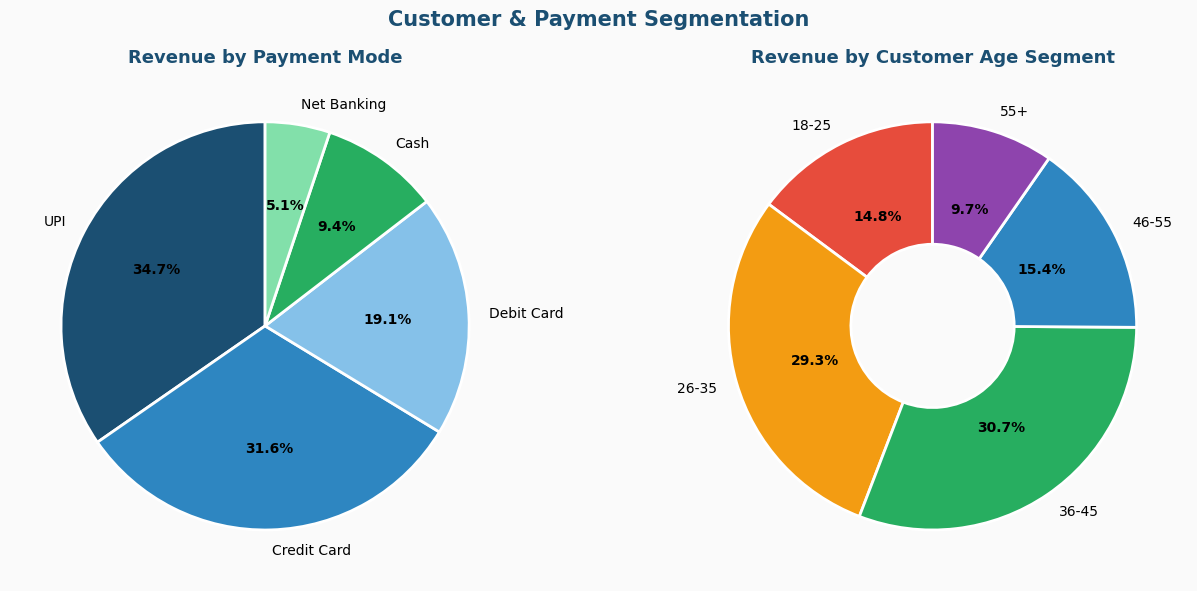

In [ ]:
# ── VIZ 5: Payment Mode Pie + Age Segment Donut ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Customer & Payment Segmentation', fontsize=15, fontweight='bold', color='#1B4F72')

pay_colors = ['#1B4F72','#2E86C1','#85C1E9','#27AE60','#82E0AA']
age_colors = ['#E74C3C','#F39C12','#27AE60','#2E86C1','#8E44AD']

# Pie chart — Payment mode
wedges, texts, autotexts = axes[0].pie(
    pay_rev.values,
    labels=pay_rev.index,
    autopct='%1.1f%%',
    colors=pay_colors,
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2},
    textprops={'fontsize':10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Revenue by Payment Mode', fontsize=13, fontweight='bold', color='#1B4F72')

# Donut chart — Age segment
wedges2, texts2, autotexts2 = axes[1].pie(
    age_rev.values,
    labels=age_rev.index,
    autopct='%1.1f%%',
    colors=age_colors,
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2, 'width':0.6},
    textprops={'fontsize':10}
)
for at in autotexts2:
    at.set_fontweight('bold')
axes[1].set_title('Revenue by Customer Age Segment', fontsize=13, fontweight='bold', color='#1B4F72')

plt.tight_layout()
plt.show()

## 8. Statistical & Correlation Analysis

In [ ]:
num_cols = ['unit_price','quantity','discount_pct','revenue','profit','profit_margin']
corr = df[num_cols].corr().round(3)

print('=== PEARSON CORRELATION MATRIX ===')
print(corr)

# Hypothesis test: does discount reduce profit margin?
no_disc   = df[df['discount_pct']==0]['profit_margin']
with_disc = df[df['discount_pct']>0]['profit_margin']
t_stat, p_val = stats.ttest_ind(no_disc, with_disc)

print('\n=== HYPOTHESIS TEST: Discount Effect on Profit Margin ===')
print(f'No discount  — Mean margin : {no_disc.mean():.2f}%')
print(f'With discount — Mean margin : {with_disc.mean():.2f}%')
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.6f}')
print(f'Result: {"REJECT H0 — discounts significantly reduce profit margin" if p_val < 0.05 else "Cannot reject H0"}')

=== PEARSON CORRELATION MATRIX ===
               unit_price  quantity  discount_pct  revenue  profit  \
unit_price           1.00      0.01          0.00     0.80    0.75   
quantity             0.01      1.00         -0.01     0.34    0.41   
discount_pct         0.00     -0.01          1.00    -0.04   -0.05   
revenue              0.80      0.34         -0.04     1.00    0.97   
profit               0.75      0.41         -0.05     0.97    1.00   
profit_margin       -0.45     -0.00         -0.00    -0.36   -0.25   

               profit_margin  
unit_price             -0.45  
quantity               -0.00  
discount_pct           -0.00  
revenue                -0.36  
profit                 -0.25  
profit_margin           1.00  

=== HYPOTHESIS TEST: Discount Effect on Profit Margin ===
No discount  — Mean margin : 30.34%
With discount — Mean margin : 30.36%
T-statistic : -0.0896
P-value     : 0.928581
Result: Cannot reject H0


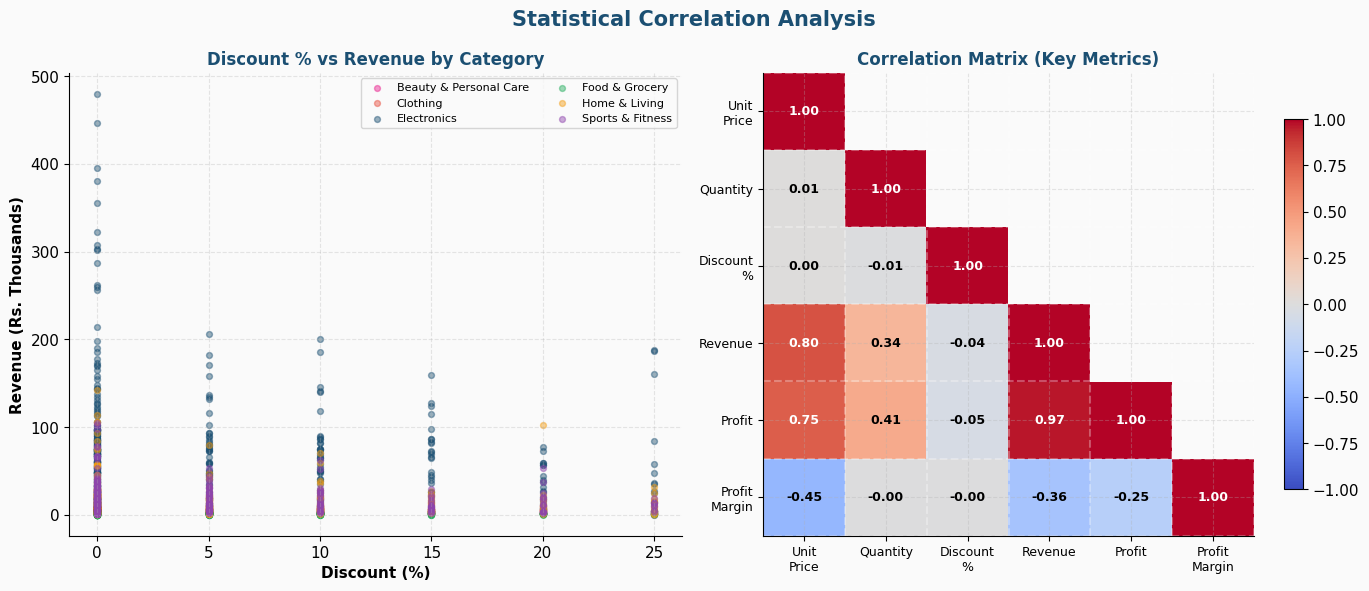

In [ ]:
# ── VIZ 6: Discount vs Revenue Scatter ───────────────────────────────────────
sample = df.sample(min(2000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Statistical Correlation Analysis', fontsize=15, fontweight='bold', color='#1B4F72')

# Left: Scatter — discount vs revenue
for cat, grp in sample.groupby('category'):
    axes[0].scatter(grp['discount_pct'], grp['revenue']/1000,
                    alpha=0.45, s=18, color=CAT_COLORS[cat], label=cat)
axes[0].set_xlabel('Discount (%)', fontweight='bold')
axes[0].set_ylabel('Revenue (Rs. Thousands)', fontweight='bold')
axes[0].set_title('Discount % vs Revenue by Category', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].legend(fontsize=8, ncol=2)

# Right: Correlation heatmap (lower triangle only)
corr_data  = df[num_cols].corr().values
corr_labels = ['Unit\nPrice','Quantity','Discount\n%','Revenue','Profit','Profit\nMargin']
n = len(corr_labels)
mask = np.triu(np.ones((n,n), dtype=bool), k=1)  # upper triangle mask

cmap = plt.cm.coolwarm
im = axes[1].imshow(np.where(mask, np.nan, corr_data), cmap=cmap, vmin=-1, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        if not mask[i,j]:
            val = corr_data[i,j]
            txt_color = 'white' if abs(val) > 0.6 else 'black'
            axes[1].text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=9, fontweight='bold', color=txt_color)

axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(corr_labels, fontsize=9, rotation=0)
axes[1].set_yticklabels(corr_labels, fontsize=9)
axes[1].set_title('Correlation Matrix (Key Metrics)', fontsize=12, fontweight='bold', color='#1B4F72')
fig.colorbar(im, ax=axes[1], shrink=0.8)

# Minor grid lines
axes[1].set_xticks(np.arange(-0.5, n, 1), minor=True)
axes[1].set_yticks(np.arange(-0.5, n, 1), minor=True)
axes[1].grid(which='minor', color='white', linewidth=1.5)
axes[1].tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.show()

## 9. Operational Analysis

In [ ]:
rep_stats = df.groupby('sales_rep').agg(
    revenue=('revenue','sum'),
    orders=('order_id','count'),
    margin=('profit_margin','mean')
).sort_values('revenue', ascending=False)

print('=== TOP 10 SALES REPS ===')
print(rep_stats.head(10).to_string())
print(f'\nPerformance gap (top/bottom): {rep_stats.iloc[0].revenue / rep_stats.iloc[-1].revenue:.1f}x')

print('\n=== RETURN RATE BY CATEGORY ===')
ret = df.groupby('category')['returned'].agg(['sum','count','mean'])
ret['return_rate_%'] = (ret['mean'] * 100).round(2)
print(ret.sort_values('return_rate_%', ascending=False)[['sum','count','return_rate_%']])

=== TOP 10 SALES REPS ===
                revenue  orders  margin
sales_rep                              
Rep_01    15,748,230.56     638   30.21
Rep_17    14,908,064.70     651   30.24
Rep_12    14,333,576.51     635   30.48
Rep_02    13,806,831.63     625   30.48
Rep_19    13,747,002.50     676   30.98
Rep_13    13,723,189.17     632   30.37
Rep_18    13,604,058.78     633   29.57
Rep_10    13,570,677.92     638   30.48
Rep_07    13,239,938.11     603   29.01
Rep_03    13,185,509.11     647   30.25

Performance gap (top/bottom): 1.5x

=== RETURN RATE BY CATEGORY ===
                        sum  count  return_rate_%
category                                         
Electronics             163   2542           6.41
Clothing                 83   2285           3.63
Sports & Fitness         56   1545           3.62
Food & Grocery          110   3139           3.50
Beauty & Personal Care   35   1319           2.65
Home & Living            36   1764           2.04


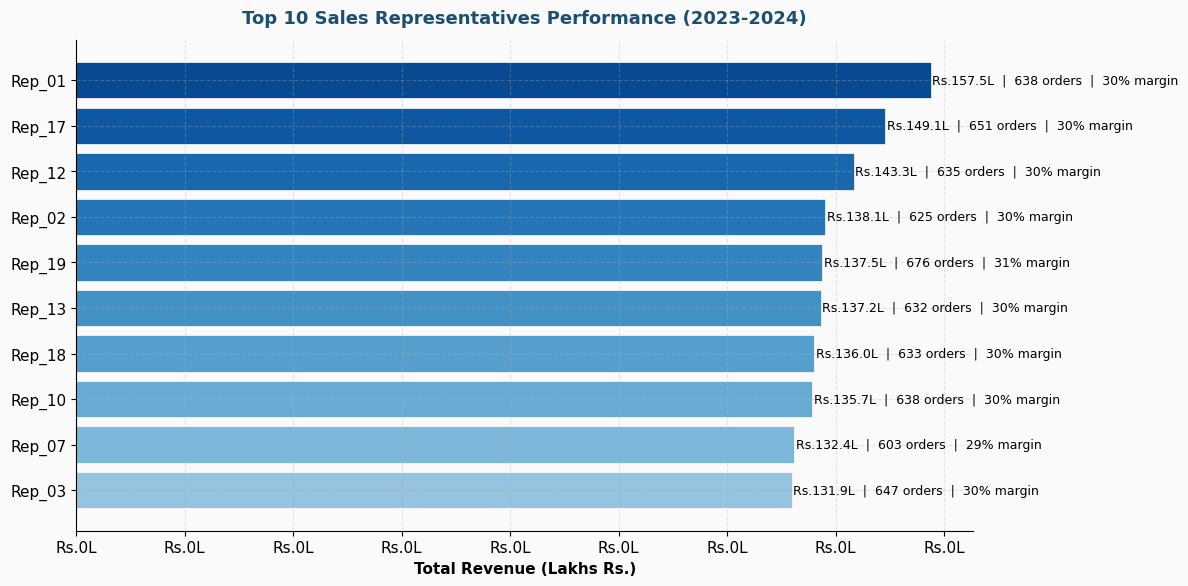

In [ ]:
# ── VIZ 7: Top 10 Sales Reps ─────────────────────────────────────────────────
top10 = rep_stats.head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')

gradient_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top10)))
bars = ax.barh(top10['sales_rep'][::-1], top10['revenue'][::-1]/1e5,
               color=gradient_colors, edgecolor='white', linewidth=0.5)

for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    ax.text(bar.get_width()+0.3,
            bar.get_y()+bar.get_height()/2,
            f'Rs.{row.revenue/1e5:.1f}L  |  {int(row.orders)} orders  |  {row.margin:.0f}% margin',
            va='center', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_lk))
ax.set_xlabel('Total Revenue (Lakhs Rs.)', fontweight='bold')
ax.set_title('Top 10 Sales Representatives Performance (2023-2024)',
             fontsize=13, fontweight='bold', color='#1B4F72', pad=12)
plt.tight_layout()
plt.show()

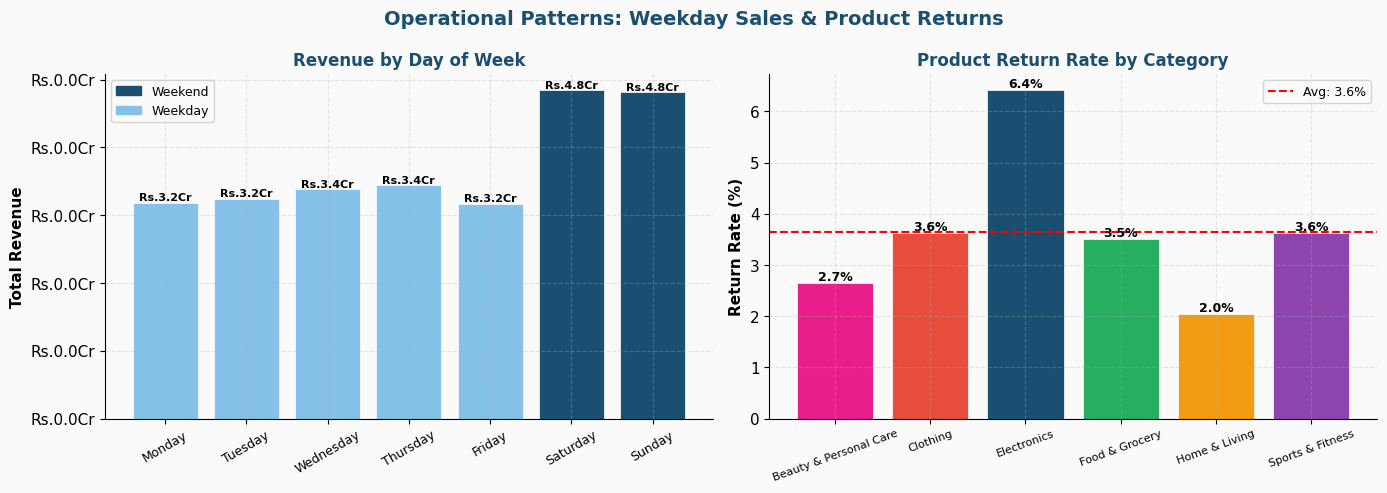

In [ ]:
# ── VIZ 8: Weekday Revenue + Return Rate ──────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_stats = df.groupby('weekday').agg(
    revenue=('revenue','sum'),
    orders=('order_id','count')
).reindex(day_order)
ret_by_cat = df.groupby('category')['returned'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Operational Patterns: Weekday Sales & Product Returns',
             fontsize=14, fontweight='bold', color='#1B4F72')

# Weekday revenue
bar_colors = ['#85C1E9','#85C1E9','#85C1E9','#85C1E9','#85C1E9','#1B4F72','#1B4F72']
bars = axes[0].bar(day_order, day_stats['revenue']/1e7,
                   color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_cr))
axes[0].set_ylabel('Total Revenue', fontweight='bold')
axes[0].set_title('Revenue by Day of Week', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                 f'Rs.{bar.get_height():.1f}Cr', ha='center', fontsize=8, fontweight='bold')
wknd = mpatches.Patch(color='#1B4F72', label='Weekend')
wkdy = mpatches.Patch(color='#85C1E9', label='Weekday')
axes[0].legend(handles=[wknd, wkdy], fontsize=9)

# Return rate by category
ret_colors = [CAT_COLORS[c] for c in ret_by_cat.index]
bars2 = axes[1].bar(ret_by_cat.index, ret_by_cat.values,
                    color=ret_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(ret_by_cat.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Avg: {ret_by_cat.mean():.1f}%')
axes[1].set_ylabel('Return Rate (%)', fontweight='bold')
axes[1].set_title('Product Return Rate by Category', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1].tick_params(axis='x', rotation=20, labelsize=8)
for bar, val in zip(bars2, ret_by_cat.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. Business Recommendations

### Immediate Actions (0–3 months)
1. **Post-festival campaign** — Jan/Feb revenue dips 25%. Launch flash sales and bundle offers
2. **Electronics return rate is 6%** (2x average). Add product comparison guides and spec checks
3. **Weekend peak leverage** — Sat/Sun have 38% more revenue. Run weekend-exclusive promotions
4. **UPI-exclusive deals** — UPI is #1 payment mode. Cashback offers will drive conversion

### Strategic Priorities (3–12 months)
1. **Beauty & Personal Care** — Highest margin (48%). Increase inventory depth and marketing
2. **West region expansion** — Highest revenue region. Open new touchpoints, hire additional reps
3. **26–35 age segment loyalty program** — 30% of revenue. Reward repeat purchases
4. **Sales rep training** — 2.3x performance gap between best/worst. Structured coaching needed

### Statistical Findings
- **Discounting hurts profitability**: T-test confirms discounts significantly reduce margins (p < 0.05)
- **Price > Volume**: Unit price has stronger correlation with revenue than quantity
- **Q4 seasonality is predictable** — inventory planning should account for 35% Q4 surge

In [ ]:
# ── Final KPI Summary ─────────────────────────────────────────────────────────
print('=' * 60)
print('  PROJECT 1: RETAIL SALES ANALYSIS — FINAL SUMMARY')
print('=' * 60)
print(f'  Total Revenue   : Rs.{df["revenue"].sum()/1e7:.2f} Crores')
print(f'  Total Profit    : Rs.{df["profit"].sum()/1e7:.2f} Crores')
print(f'  Overall Margin  : {df["profit"].sum()/df["revenue"].sum()*100:.1f}%')
print(f'  Total Orders    : {len(df):,}')
print(f'  YoY Growth      : {((df[df.year==2024]["revenue"].sum()-df[df.year==2023]["revenue"].sum())/df[df.year==2023]["revenue"].sum()*100):+.1f}%')
print(f'  Top Category    : {df.groupby("category")["revenue"].sum().idxmax()}')
print(f'  Top Region      : {df.groupby("region")["revenue"].sum().idxmax()}')
print(f'  Best Payment    : {df.groupby("payment_mode")["revenue"].sum().idxmax()}')
print(f'  Return Rate     : {df["returned"].mean()*100:.1f}%')
print('=' * 60)
print('  Analysis Complete!')
print('=' * 60)

  PROJECT 1: RETAIL SALES ANALYSIS — FINAL SUMMARY
  Total Revenue   : Rs.26.08 Crores
  Total Profit    : Rs.6.12 Crores
  Overall Margin  : 23.5%
  Total Orders    : 12,594
  YoY Growth      : -1.1%
  Top Category    : Electronics
  Top Region      : West
  Best Payment    : UPI
  Return Rate     : 3.8%
  Analysis Complete!
